# Output Validation

Set `RUN_NUMBER` in the first code cell, then run the notebook.

In [2]:
from pathlib import Path
import json
import pickle
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
from sklearn.decomposition import PCA

RUN_NUMBER = 15  # change this number to load a different pipeline run

SRC_DIR = Path.cwd() / "classic_methods" / "src"
if not SRC_DIR.exists():
    SRC_DIR = Path.cwd() / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

OUTPUT_ROOT_CANDIDATES = [Path.cwd() / "classic_methods" / "output", Path.cwd() / "output"]
OUTPUT_DIR = None
for root in OUTPUT_ROOT_CANDIDATES:
    candidate = root / f"run{RUN_NUMBER}"
    if candidate.exists():
        OUTPUT_DIR = candidate
        break
if OUTPUT_DIR is None:
    raise FileNotFoundError(f"Could not find output/run{RUN_NUMBER} in any known output folder.")

MANIFEST_PATH = OUTPUT_DIR / "manifest.json"
manifest = json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))
print("Output directory:", OUTPUT_DIR)
manifest

Output directory: c:\Users\lovro\Desktop\hackatoni\LUMEN2026\classic_methods\output\run15


{'dataframe': 'C:\\Users\\lovro\\Desktop\\hackatoni\\LUMEN2026\\classic_methods\\output\\run15\\dataframe.csv',
 'idx2item': 'C:\\Users\\lovro\\Desktop\\hackatoni\\LUMEN2026\\classic_methods\\output\\run15\\idx2item.json',
 'embedding': 'C:\\Users\\lovro\\Desktop\\hackatoni\\LUMEN2026\\classic_methods\\output\\run15\\embedding.npy',
 'model': 'C:\\Users\\lovro\\Desktop\\hackatoni\\LUMEN2026\\classic_methods\\output\\run15\\model.pkl',
 'clusters': 'C:\\Users\\lovro\\Desktop\\hackatoni\\LUMEN2026\\classic_methods\\output\\run15\\clusters.npy',
 'user_user_matrix': 'C:\\Users\\lovro\\Desktop\\hackatoni\\LUMEN2026\\classic_methods\\output\\run15\\user_user_matrix.npz',
 'user_item_matrix': 'C:\\Users\\lovro\\Desktop\\hackatoni\\LUMEN2026\\classic_methods\\output\\run15\\user_item_matrix.npz',
 'customer_idx': 'C:\\Users\\lovro\\Desktop\\hackatoni\\LUMEN2026\\classic_methods\\output\\run15\\customer_idx.npy',
 'item_idx': 'C:\\Users\\lovro\\Desktop\\hackatoni\\LUMEN2026\\classic_methods\\o

In [ ]:
def load_outputs(output_dir: Path):
    """Load the saved pipeline artifacts from disk."""
    dataframe = pd.read_csv(output_dir / "dataframe.csv")
    embedding = np.load(output_dir / "embedding.npy")
    clusters = np.load(output_dir / "clusters.npy")
    customer_idx = np.load(output_dir / "customer_idx.npy")
    item_idx = np.load(output_dir / "item_idx.npy")
    idx2item = json.loads((output_dir / "idx2item.json").read_text(encoding="utf-8"))
    user_user_matrix = sp.load_npz(output_dir / "user_user_matrix.npz")
    user_item_matrix = sp.load_npz(output_dir / "user_item_matrix.npz")
    similarity_matrix = sp.load_npz(output_dir / "similarity_matrix.npz")
    with open(output_dir / "model.pkl", "rb") as handle:
        model = pickle.load(handle)

    return {
        "dataframe": dataframe,
        "embedding": embedding,
        "clusters": clusters,
        "customer_idx": customer_idx,
        "item_idx": item_idx,
        "idx2item": idx2item,
        "user_user_matrix": user_user_matrix,
        "user_item_matrix": user_item_matrix,
        "similarity_matrix": similarity_matrix,
        "model": model,
    }


artifacts = load_outputs(OUTPUT_DIR)
for key, value in artifacts.items():
    if hasattr(value, "shape"):
        print(f"{key}: shape={value.shape}")
    else:
        print(f"{key}: type={type(value).__name__}")

dataframe: shape=(759621, 35)
embedding: shape=(710, 10)
clusters: shape=(710,)
customer_idx: shape=(710,)
item_idx: shape=(5404,)
idx2item: type=list
user_user_matrix: shape=(710, 710)
user_item_matrix: shape=(710, 5404)
similarity_matrix: shape=(6114, 6114)
model: type=katz_recommender


: 

: 

In [ ]:
dataframe = artifacts["dataframe"]
embedding = artifacts["embedding"]
clusters = artifacts["clusters"]
customer_idx = artifacts["customer_idx"]
item_idx = artifacts["item_idx"]
idx2item = artifacts["idx2item"]
model = artifacts["model"]

print("Rows:", len(dataframe))
print("Customers:", len(customer_idx))
print("Items:", len(item_idx))
print("Embedding shape:", embedding.shape)
print("Unique clusters:", np.unique(clusters).size)
print("Sample customer ids:", customer_idx[:5])

Rows: 759621
Customers: 710
Items: 5404
Embedding shape: (710, 10)
Unique clusters: 4
Sample customer ids: [224307 224029 224600 223521  31072]


: 

: 

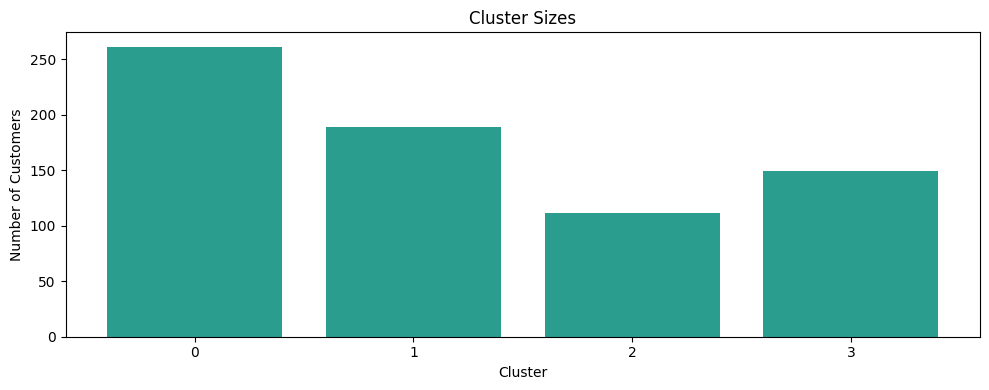

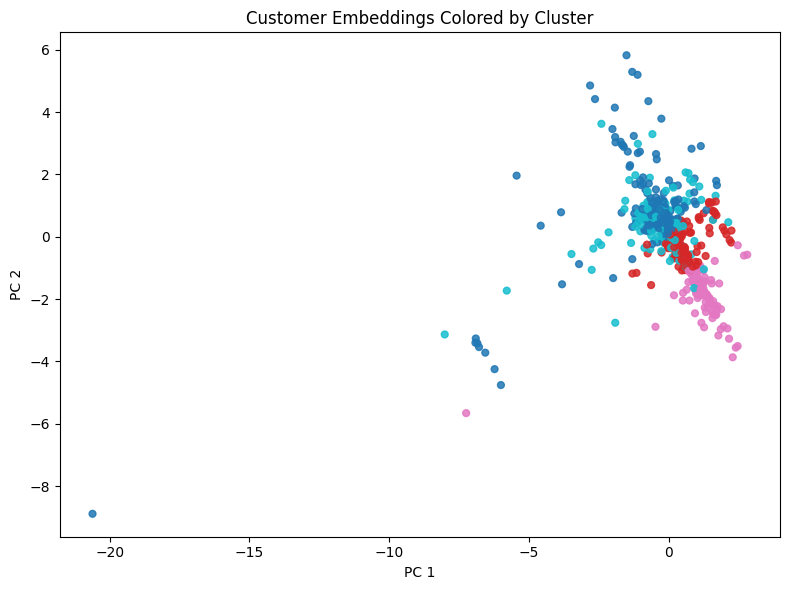

: 

: 

In [ ]:
unique_clusters, counts = np.unique(clusters, return_counts=True)
plt.figure(figsize=(10, 4))
plt.bar(unique_clusters.astype(str), counts, color="#2a9d8f")
plt.title("Cluster Sizes")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

if embedding.shape[1] >= 2:
    pca = PCA(n_components=2, random_state=42)
    emb_2d = pca.fit_transform(embedding)
    plt.figure(figsize=(8, 6))
    plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=clusters, cmap="tab10", s=24, alpha=0.85)
    plt.title("Customer Embeddings Colored by Cluster")
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.tight_layout()
    plt.show()

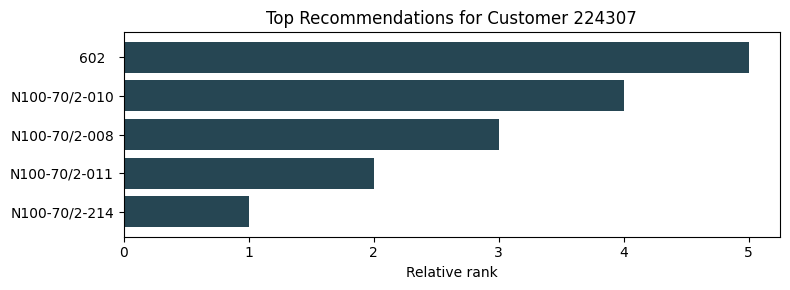

Customer 224307: ['602  ', 'N100-70/2-010', 'N100-70/2-008', 'N100-70/2-011', 'N100-70/2-214']


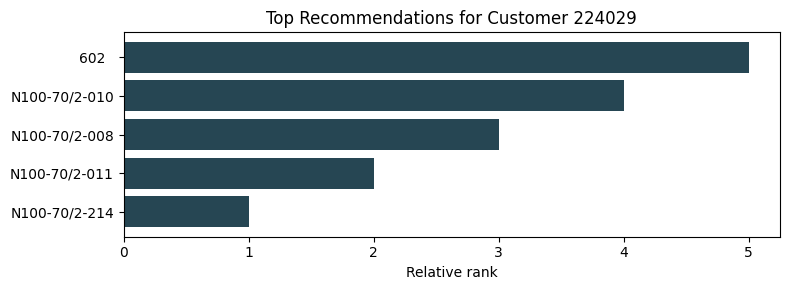

Customer 224029: ['602  ', 'N100-70/2-010', 'N100-70/2-008', 'N100-70/2-011', 'N100-70/2-214']


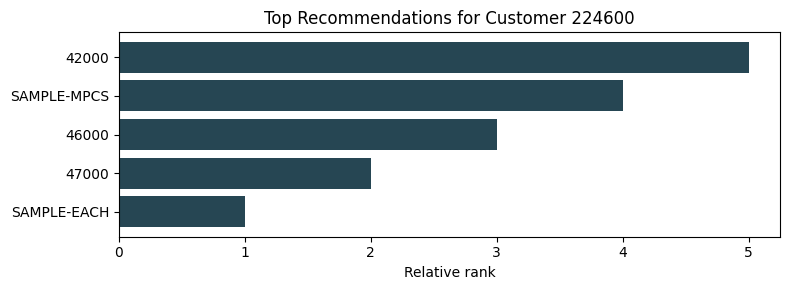

Customer 224600: ['42000', 'SAMPLE-MPCS', '46000', '47000', 'SAMPLE-EACH']


: 

: 

In [ ]:
def pretty_item(item_id):
    return idx2item[item_id] if item_id < len(idx2item) else item_id


for customer_id in customer_idx[:3]:
    recs = model.predict(int(customer_id), num_prediction=5)
    labels = [str(pretty_item(item_id)) for item_id in recs]
    scores = list(range(len(labels), 0, -1))

    plt.figure(figsize=(8, 3))
    plt.barh(labels[::-1], scores[::-1], color="#264653")
    plt.title(f"Top Recommendations for Customer {customer_id}")
    plt.xlabel("Relative rank")
    plt.tight_layout()
    plt.show()

    print(f"Customer {customer_id}: {labels}")

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_csv(r"C:\Users\lovro\Desktop\hackatoni\LUMEN2026\classic_methods\output\run15\dataframe.csv")

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 759621 entries, 0 to 759620
Data columns (total 35 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   Manufacturing Region                 759621 non-null  str    
 1   Manufacturing Location Code          759621 non-null  str    
 2   Intercompany                         759621 non-null  str    
 3   CustomerID                           759621 non-null  int64  
 4   Customer industry                    759621 non-null  str    
 5   Customer Region                      759621 non-null  str    
 6   Customer First Invoice Date          759621 non-null  str    
 7   Top Customer Group                   759621 non-null  str    
 8   Item Code                            759621 non-null  str    
 9   Product family                       759621 non-null  str    
 10  Product group                        759621 non-null  str    
 11  Price last modified date

: 

: 